In [1]:
!pip install mlflow scikit-learn seaborn -q

import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import mlflow
import mlflow.keras
import keras
from sklearn.metrics import (confusion_matrix, classification_report,
                             precision_score, recall_score, f1_score)

# Configuración MLflow
MLFLOW_TRACKING_URI = "http://35.175.247.42:8080"
EXPERIMENT_NAME     = "Kata_MNIST_CNN"

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(EXPERIMENT_NAME)
print(f"TF: {tf.__version__} | Keras: {keras.__version__}")
print(f"MLflow conectado: {MLFLOW_TRACKING_URI}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 4.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 5.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 90.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 118.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 90.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.5/857.5 kB 34.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

#Datos y preprocesamiento

In [2]:
(x_train_raw, y_train), (x_test_raw, y_test) = keras.datasets.mnist.load_data()

def preprocess_input(images):
    images = np.array(images)
    if images.ndim == 2:
        images = np.expand_dims(images, 0)
    img_normalized = images.astype("float32") / 255.0
    img_reshaped   = np.expand_dims(img_normalized, -1)
    return img_reshaped

x_train = preprocess_input(x_train_raw)
x_test  = preprocess_input(x_test_raw)

assert x_train.shape[1:] == (28, 28, 1)
assert x_test.shape[1:]  == (28, 28, 1)
assert np.max(x_train)   <= 1.0
assert np.min(x_train)   >= 0.0

print(f"Train: {x_train.shape} | Test: {x_test.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Train: (60000, 28, 28, 1) | Test: (10000, 28, 28, 1)


#Modelos

In [3]:
MODEL_NAME = "CNN_Base"   # CNN_Base | CNN_Deep | CNN_BN

def build_model(model_name="CNN_Base"):

    if model_name == "CNN_Base":
        # Arquitectura original
        model = keras.Sequential([
            keras.Input(shape=(28, 28, 1)),
            keras.layers.Conv2D(32, (3,3), activation="relu", padding="same"),
            keras.layers.MaxPooling2D((2,2)),
            keras.layers.Conv2D(64, (3,3), activation="relu", padding="same"),
            keras.layers.MaxPooling2D((2,2)),
            keras.layers.Flatten(),
            keras.layers.Dropout(0.5),
            keras.layers.Dense(10, activation="softmax")
        ])

    elif model_name == "CNN_Deep":
        # Más capas convolucionales
        model = keras.Sequential([
            keras.Input(shape=(28, 28, 1)),
            keras.layers.Conv2D(32, (3,3), activation="relu", padding="same"),
            keras.layers.Conv2D(32, (3,3), activation="relu", padding="same"),
            keras.layers.MaxPooling2D((2,2)),
            keras.layers.Conv2D(64, (3,3), activation="relu", padding="same"),
            keras.layers.Conv2D(64, (3,3), activation="relu", padding="same"),
            keras.layers.MaxPooling2D((2,2)),
            keras.layers.Flatten(),
            keras.layers.Dropout(0.5),
            keras.layers.Dense(10, activation="softmax")
        ])

    elif model_name == "CNN_BN":
        # Con Batch Normalization
        model = keras.Sequential([
            keras.Input(shape=(28, 28, 1)),
            keras.layers.Conv2D(32, (3,3), activation="relu", padding="same"),
            keras.layers.BatchNormalization(),
            keras.layers.MaxPooling2D((2,2)),
            keras.layers.Conv2D(64, (3,3), activation="relu", padding="same"),
            keras.layers.BatchNormalization(),
            keras.layers.MaxPooling2D((2,2)),
            keras.layers.Flatten(),
            keras.layers.Dropout(0.3),
            keras.layers.Dense(10, activation="softmax")
        ])

    model.compile(
        loss="sparse_categorical_crossentropy",
        optimizer="adam",
        metrics=["accuracy"]
    )
    return model

model = build_model(MODEL_NAME)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        31,370 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,186 (196.04 KB)

 Trainable params: 50,186 (196.04 KB)

 Non-trainable params: 0 (0.00 B)

#Entrenamiento

In [4]:
EPOCHS     = 5
BATCH_SIZE = 128

if mlflow.active_run():
    mlflow.end_run()

with mlflow.start_run(run_name=f"Entrenamiento_{MODEL_NAME}"):

    mlflow.log_params({
        "model_name":    MODEL_NAME,
        "epochs":        EPOCHS,
        "batch_size":    BATCH_SIZE,
        "optimizer":     "adam",
        "dropout_rate":  0.5,
        "total_params":  model.count_params()
    })

    # Entrenamiento
    start_time = time.time()
    history = model.fit(
        x_train, y_train,
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        validation_split=0.1,
        verbose=1
    )
    training_time = time.time() - start_time
    mlflow.log_metric("training_time_seconds", round(training_time, 2))

    # Métricas por época
    for epoch in range(EPOCHS):
        mlflow.log_metrics({
            "train_loss":     history.history['loss'][epoch],
            "train_accuracy": history.history['accuracy'][epoch],
            "val_loss":       history.history['val_loss'][epoch],
            "val_accuracy":   history.history['val_accuracy'][epoch],
        }, step=epoch)

    # Mejor época
    best_val_acc = max(history.history['val_accuracy'])
    best_epoch   = history.history['val_accuracy'].index(best_val_acc)
    mlflow.log_metrics({
        "best_val_accuracy": best_val_acc,
        "best_epoch":        best_epoch + 1
    })

    # Evaluación test
    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
    mlflow.log_metrics({"test_loss": test_loss, "test_accuracy": test_acc})

    # Predicciones
    y_pred = np.argmax(model.predict(x_test, verbose=0), axis=1)

    # Precision, Recall, F1
    mlflow.log_metrics({
        "precision_macro":    precision_score(y_test, y_pred, average='macro'),
        "recall_macro":       recall_score(y_test, y_pred, average='macro'),
        "f1_macro":           f1_score(y_test, y_pred, average='macro'),
        "precision_weighted": precision_score(y_test, y_pred, average='weighted'),
        "recall_weighted":    recall_score(y_test, y_pred, average='weighted'),
        "f1_weighted":        f1_score(y_test, y_pred, average='weighted'),
    })

    # F1 por clase
    for digit, f1 in enumerate(f1_score(y_test, y_pred, average=None)):
        mlflow.log_metric(f"f1_class_{digit}", f1)

    # Guardar modelos
    model.save(f"modelo_{MODEL_NAME}.keras")
    model.save(f"modelo_{MODEL_NAME}.h5")
    mlflow.log_artifact(f"modelo_{MODEL_NAME}.keras")
    mlflow.log_artifact(f"modelo_{MODEL_NAME}.h5")

    print(f"Entrenamiento finalizado en {training_time:.1f}s")
    print(f"Mejor val_accuracy: {best_val_acc:.4f} (época {best_epoch+1})")
    print(f"Test accuracy: {test_acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=[str(i) for i in range(10)]))

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 17s 18ms/step - accuracy: 0.8956 - loss: 0.3477 - val_accuracy: 0.9780 - val_loss: 0.0775
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9685 - loss: 0.1016 - val_accuracy: 0.9855 - val_loss: 0.0556
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9756 - loss: 0.0787 - val_accuracy: 0.9865 - val_loss: 0.0520
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9796 - loss: 0.0654 - val_accuracy: 0.9877 - val_loss: 0.0502
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9826 - loss: 0.0571 - val_accuracy: 0.9895 - val_loss: 0.0400


Entrenamiento finalizado en 25.8s
Mejor val_accuracy: 0.9895 (época 5)
Test accuracy: 0.9892
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.98      0.99      1028
           8       0.98      0.99      0.98       974
           9       0.99      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000

🏃 View run Entrenamiento_CNN_Base at: http://35.175.247.42:8080/#/experiments/1/runs/0380b939d7894b7481245e4f10a70e47
🧪 View experiment at: http://3

# Graficas y analisis

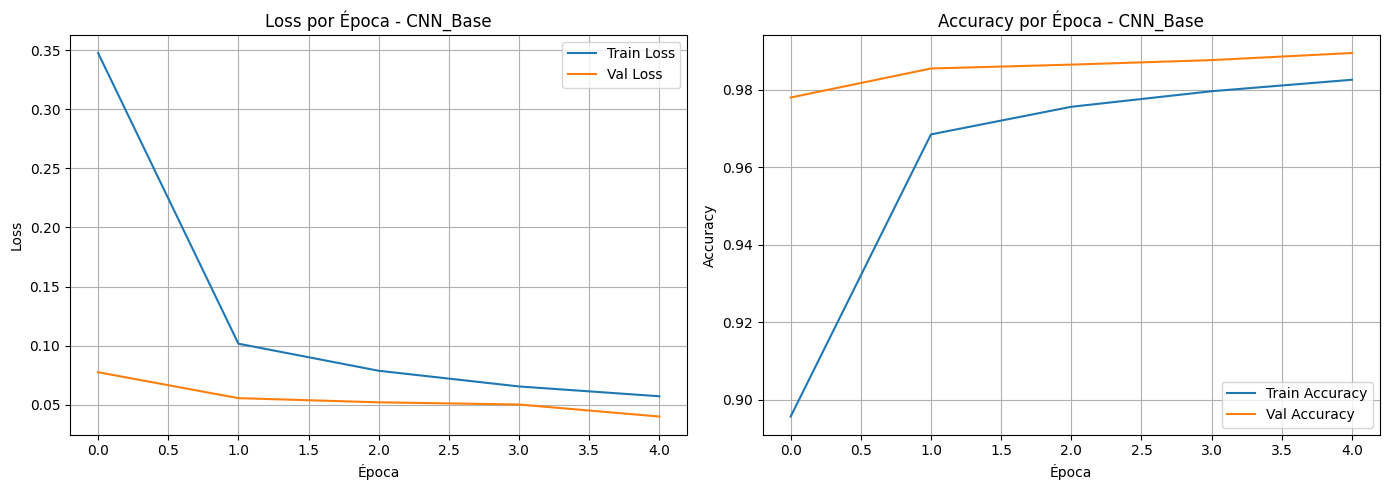

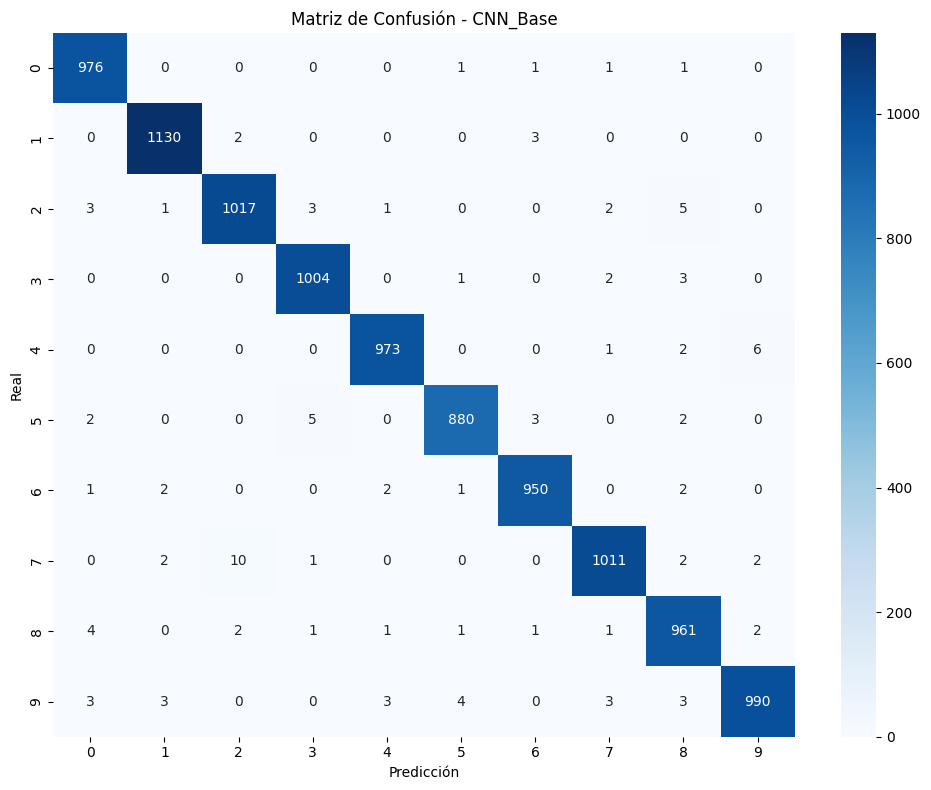

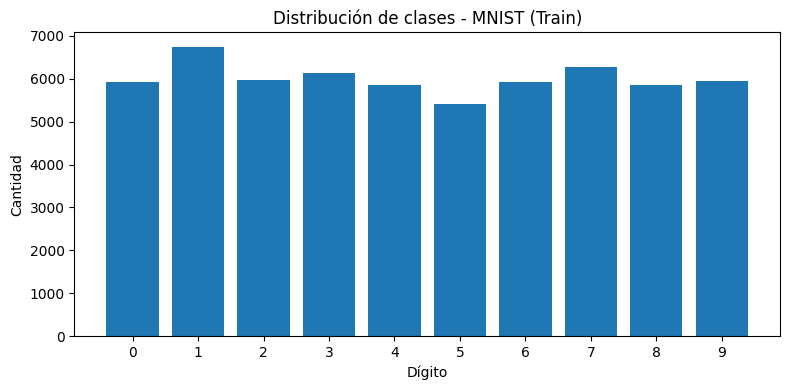

In [5]:
# Curvas de entrenamiento
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title(f'Loss por Época - {MODEL_NAME}')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(history.history['accuracy'],     label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title(f'Accuracy por Época - {MODEL_NAME}')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig(f"training_curves_{MODEL_NAME}.png")
mlflow.log_artifact(f"training_curves_{MODEL_NAME}.png")
plt.show()

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10), ax=ax)
ax.set_xlabel('Predicción')
ax.set_ylabel('Real')
ax.set_title(f'Matriz de Confusión - {MODEL_NAME}')
plt.tight_layout()
plt.savefig(f"confusion_matrix_{MODEL_NAME}.png")
mlflow.log_artifact(f"confusion_matrix_{MODEL_NAME}.png")
plt.show()

# Distribución de clases
classes, counts = np.unique(y_train, return_counts=True)
plt.figure(figsize=(8, 4))
plt.bar(classes, counts)
plt.xticks(classes)
plt.title("Distribución de clases - MNIST (Train)")
plt.xlabel("Dígito"); plt.ylabel("Cantidad")
plt.tight_layout()
plt.savefig("distribucion_clases.png")
mlflow.log_artifact("distribucion_clases.png")
mlflow.log_metrics({
    "min_class_count": int(counts.min()),
    "max_class_count": int(counts.max())
})
plt.show()